# Machine Learning Analysis

In this section, we apply machine learning techniques to examine whether Bitcoin returns can be predicted using the returns of the S&P 500 and Gold.

In [16]:
!pip install yfinance seaborn scipy scikit-learn

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

start_date = "2020-01-01"
end_date = "2026-03-31"

btc = yf.download("BTC-USD", start=start_date, end=end_date, progress=False)
sp500 = yf.download("^GSPC", start=start_date, end=end_date, progress=False)
gold = yf.download("GC=F", start=start_date, end=end_date, progress=False)

btc_close = btc['Close'].squeeze()
sp500_close = sp500['Close'].squeeze()
gold_close = gold['Close'].squeeze()

if isinstance(btc_close, pd.DataFrame):
    btc_close = btc_close.iloc[:, 0]
if isinstance(sp500_close, pd.DataFrame):
    sp500_close = sp500_close.iloc[:, 0]
if isinstance(gold_close, pd.DataFrame):
    gold_close = gold_close.iloc[:, 0]

btc_close.name = 'BTC'
sp500_close.name = 'SP500'
gold_close.name = 'Gold'

data = pd.concat([btc_close, sp500_close, gold_close], axis=1)
data = data.ffill().dropna()

returns = data.pct_change().dropna()

returns.head()

/tmp/ipykernel_1557/347219655.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start=start_date, end=end_date, progress=False)
/tmp/ipykernel_1557/347219655.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start=start_date, end=end_date, progress=False)
/tmp/ipykernel_1557/347219655.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start=start_date, end=end_date, progress=False)


,BTC,SP500,Gold
Date,,,
2020-01-03,0.051452,-0.007060,0.016202
2020-01-04,0.008955,0.000000,0.000000
2020-01-05,0.000089,0.000000,0.000000
2020-01-06,0.048291,0.003533,0.010973
2020-01-07,0.050774,-0.002803,0.003576


## Data Preparation for Machine Learning

In [17]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = returns[['SP500', 'Gold']]
y = returns['BTC']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(X_train.shape, X_test.shape)

(1823, 2) (456, 2)


## Linear Regression Model

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(X_test)

## Model Evaluation

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 6))
print("R² Score:", round(r2, 4))

Mean Squared Error: 0.000502
R² Score: 0.1244


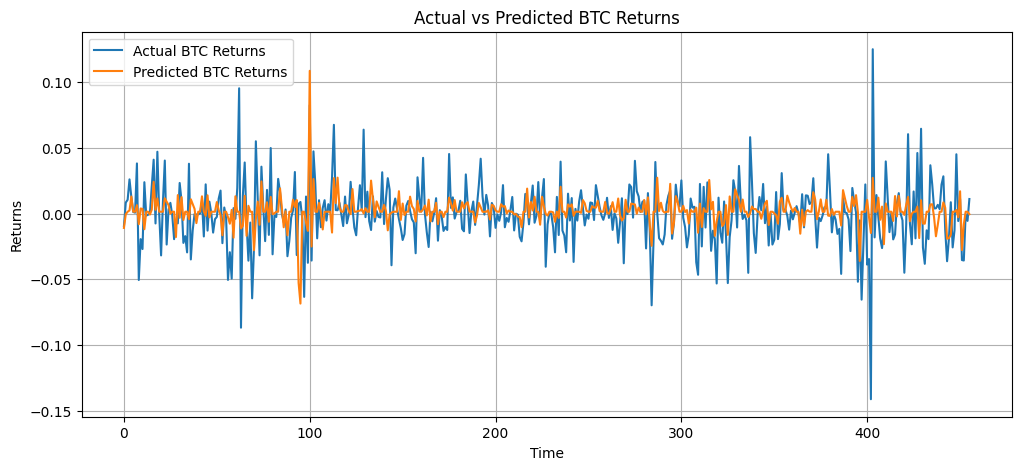

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual BTC Returns")
plt.plot(y_pred, label="Predicted BTC Returns")
plt.title("Actual vs Predicted BTC Returns")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual BTC Returns")
plt.plot(y_pred, label="Predicted BTC Returns")
plt.title("Actual vs Predicted BTC Returns")
plt.legend()
plt.show()

## Interpretation

The linear regression model attempts to predict Bitcoin returns using the returns of the S&P 500 and Gold.

The R² score indicates how well the model explains the variation in Bitcoin returns. A low R² value suggests that these variables alone are not sufficient to accurately predict Bitcoin movements.

This result aligns with earlier findings, indicating that while Bitcoin is correlated with traditional assets, it is still influenced by additional factors not captured in this model.

In [22]:
print("Model Coefficients:")
print("SP500 weight:", model.coef_[0])
print("Gold weight:", model.coef_[1])

Model Coefficients:
SP500 weight: 1.0370743064231134
Gold weight: 0.290912613108653


The model coefficients indicate how strongly each asset influences Bitcoin returns. A higher coefficient suggests a stronger relationship.